Step   | Avg Mu     | Max Mu     | Loss        
--------------------------------------------------
25     | 0.00066    | 0.00500    | 4.981695e-34
50     | 0.00284    | 0.09500    | 1.974807e-33
75     | 0.00111    | 0.00500    | 1.978137e-33
100    | 0.00329    | 0.09500    | 2.962394e-33
125    | 0.00156    | 0.00500    | 2.965001e-33
150    | 0.00374    | 0.09500    | 4.441502e-33


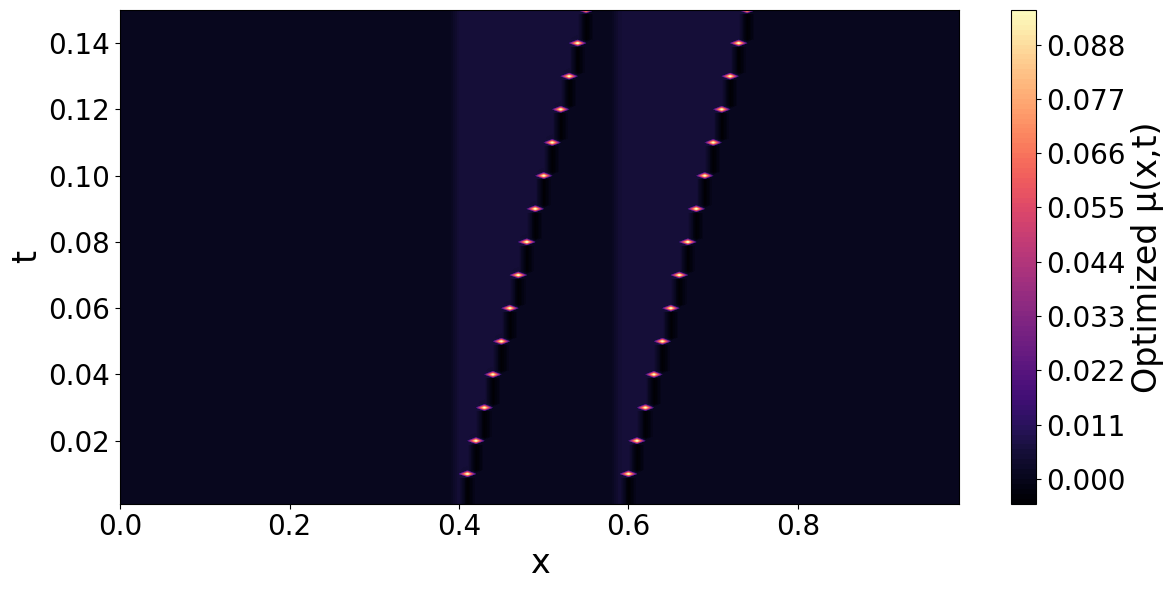

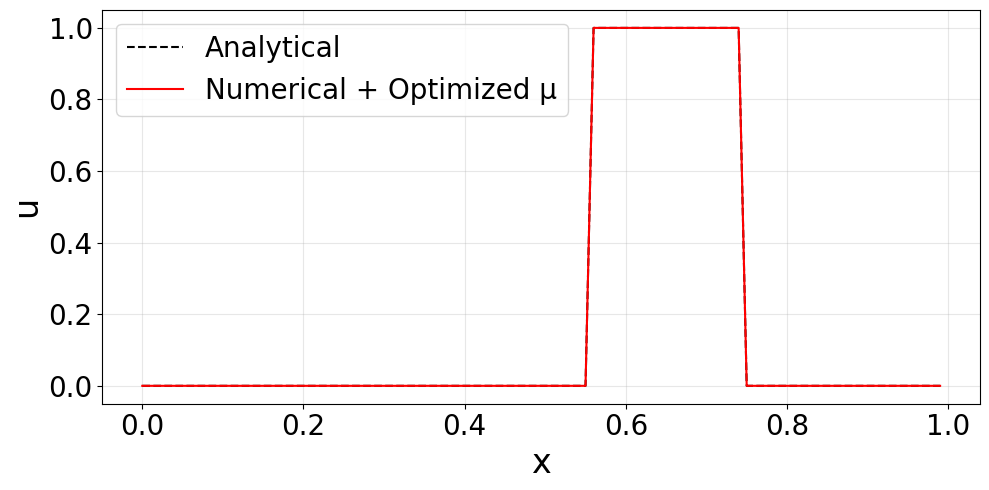

In [1]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Simulation setup
# -----------------------------
L, N = 1.0, 100           # domain length and number of grid points
dx = L / N
c, dt = 1.0, 0.001        # advection speed and time step
total_steps = 150          # total time steps
epochs_per_step = 300      # gradient descent steps per time step
lr_mu = 0.008              # learning rate for μ

# Grid
x = np.linspace(0, L, N, endpoint=False)

# Initial condition: hat function
u_initial = np.zeros(N)
u_initial[(x > 0.4) & (x < 0.6)] = 1.0
u_num = u_initial.copy()

# Initialize μ vector
mu_xt = np.ones(N) * (c**2 * dt / 2.0)  # initial guess
mu_history = []
time_history = []
u_history = []
u_exact_history = []

print(f"{'Step':<6} | {'Avg Mu':<10} | {'Max Mu':<10} | {'Loss':<12}")
print("-"*50)

# -----------------------------
# 2. Time-stepping with vector μ optimization
# -----------------------------
for n in range(1, total_steps + 1):
    t = n * dt
    # Exact solution: periodic shift
    shift = int(c * n * dt / dx)
    u_exact = np.roll(u_initial, shift)
    
    u_old = u_num.copy()
    u_p = np.roll(u_old, -1)
    u_m = np.roll(u_old, 1)
    
    # FTCS central advection term
    adv_term = - (c * dt / (2*dx)) * (u_p - u_m)
    laplacian_term = (u_p - 2*u_old + u_m) * (dt / dx**2)
    
    # Gradient descent to optimize μ locally
    for _ in range(epochs_per_step):
        u_next = u_old + adv_term + mu_xt * laplacian_term
        error = u_next - u_exact
        grad_mu = 2 * error * laplacian_term
        mu_xt -= lr_mu * grad_mu
        # Constrain μ to be non-negative and stable
        mu_xt = np.clip(mu_xt, - 0.15, 0.5)
    
    # Final update
    u_num = u_old + adv_term + mu_xt * laplacian_term
    
    # Store results
    mu_history.append(mu_xt.copy())
    time_history.append(t)
    u_history.append(u_num.copy())
    u_exact_history.append(u_exact.copy())

    # Print progress every 25 steps
    if n % 25 == 0:
        loss = np.mean((u_num - u_exact)**2)
        print(f"{n:<6} | {np.mean(mu_xt):<10.5f} | {np.max(mu_xt):<10.5f} | {loss:<12.6e}")

U_num = np.array(u_history).T        # shape: (Nx, Nt)
U_exact = np.array(u_exact_history).T
ERROR = U_num - U_exact

# -----------------------------
# 3. Contour plot of μ(x,t)
# -----------------------------
MU_data = np.array(mu_history).T
T, X = np.meshgrid(time_history, x)

plt.figure(figsize=(12,6))

cp = plt.contourf(X, T, MU_data, levels=100, cmap='magma')

cbar = plt.colorbar(cp)
cbar.set_label('Optimized μ(x,t)', fontsize=24)
cbar.ax.tick_params(labelsize=20)

plt.xlabel('x', fontsize=24)
plt.ylabel('t', fontsize=24)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.tight_layout()
plt.show()


# -----------------------------
# 4. Compare numerical vs analytical solution
# -----------------------------
u_final_exact = np.roll(u_initial, int(c * total_steps * dt / dx))
plt.figure(figsize=(10,5))

plt.plot(x, u_final_exact, 'k--', label='Analytical')
plt.plot(x, u_num, 'r', label='Numerical + Optimized μ')

plt.xlabel('x', fontsize=24)
plt.ylabel('u', fontsize=24)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.legend(fontsize=20)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


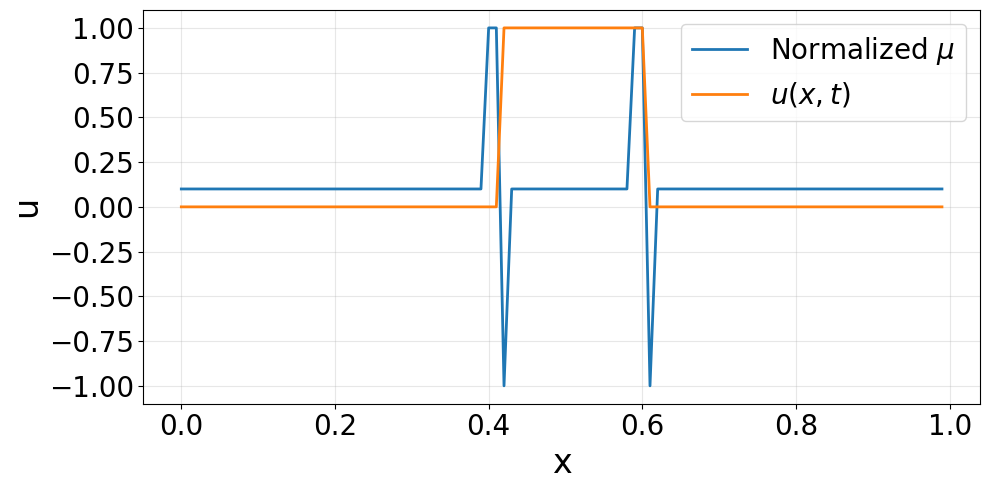

In [2]:
t1 = 10

plt.figure(figsize=(10,5))

plt.plot(
    x,
    MU_data[:, t1] / np.max(np.abs(MU_data[:, t1])),
    label='Normalized $\mu$',
    linewidth=2
)
plt.plot(
    x,
    u_history[t1],
    label='$u(x,t)$',
    linewidth=2
)

plt.xlabel('x', fontsize=24)
plt.ylabel('u', fontsize=24)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.legend(fontsize=20)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


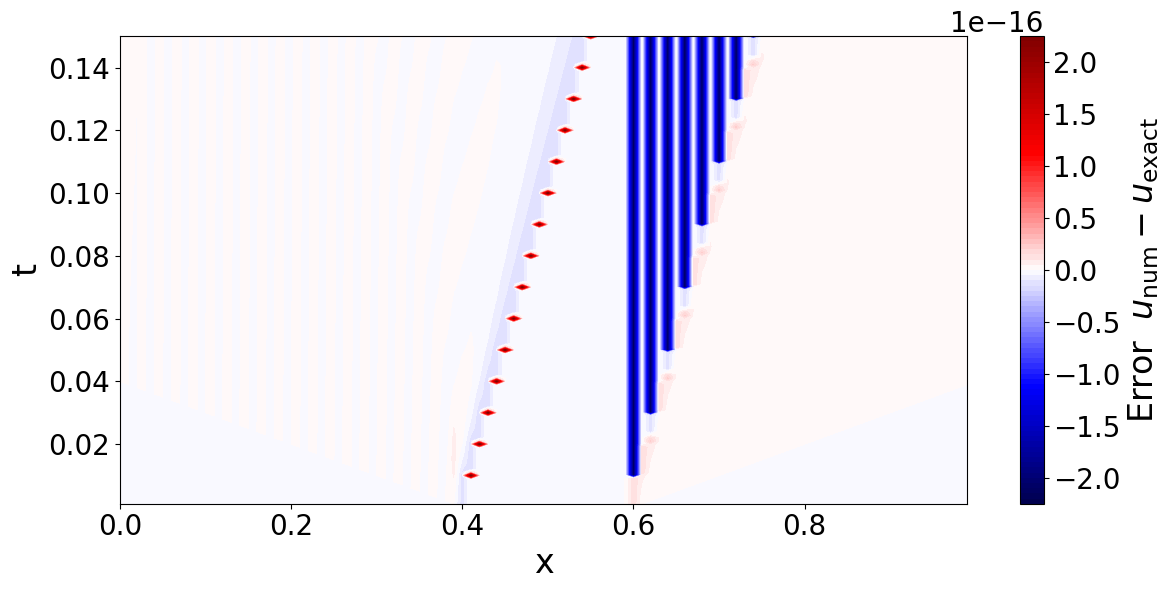

In [3]:
plt.figure(figsize=(12,6))

cp = plt.contourf(
    X, T, ERROR,
    levels=100,
    cmap='seismic'
)

cbar = plt.colorbar(cp)

# Colorbar label
cbar.set_label(
    r'Error  $u_{\mathrm{num}}-u_{\mathrm{exact}}$',
    fontsize=24
)

# Colorbar tick labels
cbar.ax.tick_params(labelsize=20)


cbar.ax.yaxis.get_offset_text().set_fontsize(20)

# Axes labels
plt.xlabel('x', fontsize=24)
plt.ylabel('t', fontsize=24)

# Axes tick labels
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.tight_layout()
plt.show()


In [4]:
print("Max mu:", np.max(MU_data))
print("min mu:", np.min(MU_data))

Max mu: 0.09500000000000003
min mu: -0.0050000000000000105


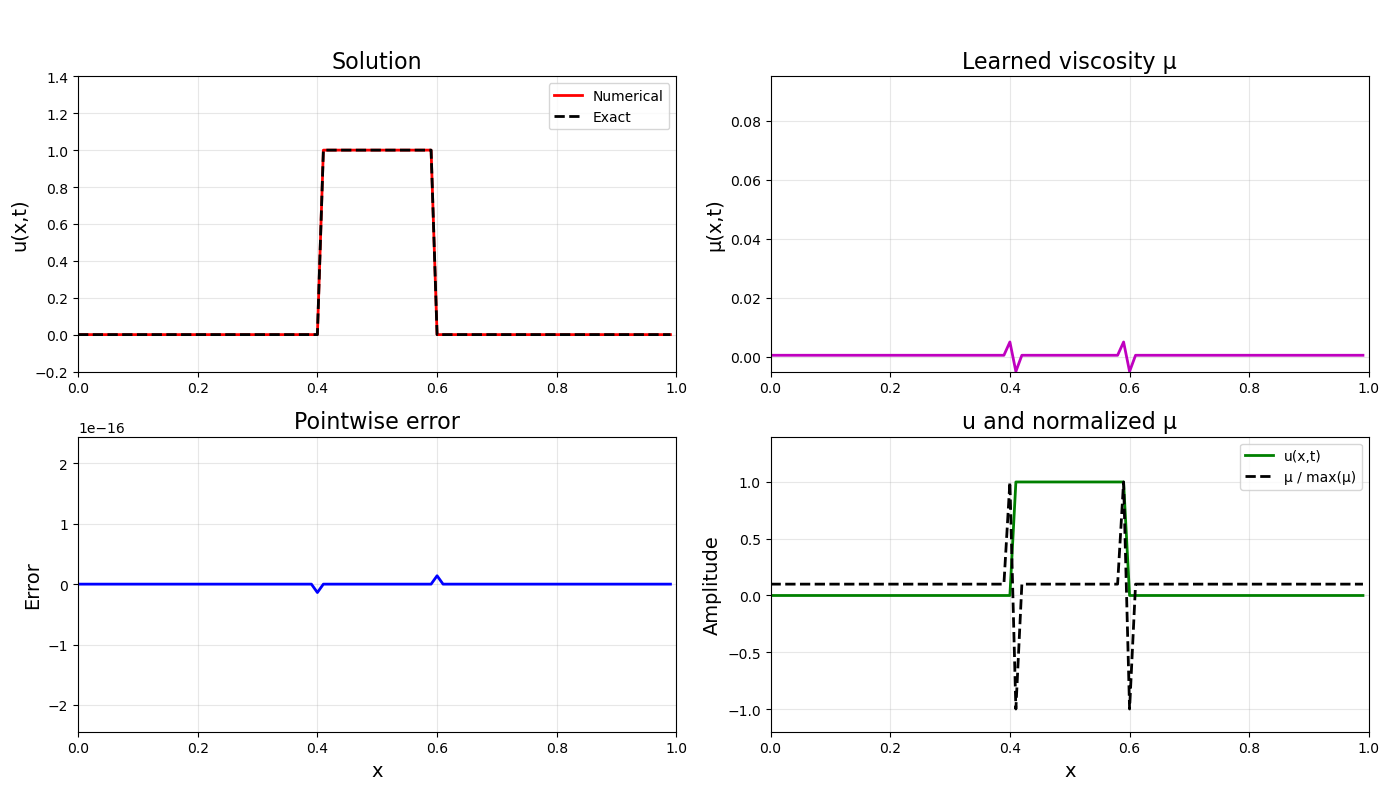

In [5]:
import matplotlib.animation as animation

# ---------------------------------
# 5. Animation: u, error, mu, u + normalized mu (overlay)
# ---------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ========= (1,1) Solution =========
ax_u = axes[0, 0]
line_num, = ax_u.plot(x, U_num[:, 0], 'r', lw=2, label='Numerical')
line_ex,  = ax_u.plot(x, U_exact[:, 0], 'k--', lw=2, label='Exact')

ax_u.set_xlim(0, L)
ax_u.set_ylim(-0.2, 1.4)
ax_u.set_ylabel('u(x,t)', fontsize=14)
ax_u.set_title('Solution', fontsize=16)
ax_u.legend()
ax_u.grid(alpha=0.3)

# ========= (1,2) Mu =========
ax_mu = axes[0, 1]
line_mu, = ax_mu.plot(x, MU_data[:, 0], 'm', lw=2)

ax_mu.set_xlim(0, L)
ax_mu.set_ylim(MU_data.min(), MU_data.max())
ax_mu.set_ylabel('μ(x,t)', fontsize=14)
ax_mu.set_title('Learned viscosity μ', fontsize=16)
ax_mu.grid(alpha=0.3)

# ========= (2,1) Error =========
ax_err = axes[1, 0]
line_err, = ax_err.plot(x, ERROR[:, 0], 'b', lw=2)

ax_err.set_xlim(0, L)
ax_err.set_ylim(1.1 * ERROR.min(), 1.1 * ERROR.max())
ax_err.set_xlabel('x', fontsize=14)
ax_err.set_ylabel('Error', fontsize=14)
ax_err.set_title('Pointwise error', fontsize=16)
ax_err.grid(alpha=0.3)

# ========= (2,2) u and normalized mu =========
ax_um = axes[1, 1]
line_u2, = ax_um.plot(x, U_num[:, 0], 'g', lw=2, label='u(x,t)')
line_mun, = ax_um.plot(x, MU_data[:, 0] / (np.max(MU_data[:, 0]) + 1e-12),
                       'k--', lw=2, label='μ / max(μ)')

ax_um.set_xlim(0, L)
ax_um.set_ylim(-1.2, 1.4)
ax_um.set_xlabel('x', fontsize=14)
ax_um.set_ylabel('Amplitude', fontsize=14)
ax_um.set_title('u and normalized μ', fontsize=16)
ax_um.legend()
ax_um.grid(alpha=0.3)

# ========= Time annotation =========
time_text = fig.text(0.5, 0.96, '', ha='center', fontsize=16)

def update(frame):
    mu = MU_data[:, frame]
    mu_norm = mu / (np.max(mu) + 1e-12)

    line_num.set_ydata(U_num[:, frame])
    line_ex.set_ydata(U_exact[:, frame])
    line_err.set_ydata(ERROR[:, frame])
    line_mu.set_ydata(mu)
    line_u2.set_ydata(U_num[:, frame])
    line_mun.set_ydata(mu_norm)

    time_text.set_text(f"t = {time_history[frame]:.4f}")

    return (
        line_num, line_ex,
        line_err,
        line_mu,
        line_u2, line_mun,
        time_text
    )

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(time_history),
    interval=60,
    blit=True
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
ani.save("advection_mu_optimized.mp4", dpi=200)
ani.save("advection_mu_optimized.gif", writer="pillow", dpi=150)
